# Validation Duck

## Paths & Co

In [1]:
new_kalman_run = True
animation = False

In [2]:
path_to_data_folder = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/'
# path_to_data_folder = '/home/jovyan/data/98_paper2_kf_dtm/'

path_tc = path_to_data_folder + '01_tides/output/'
path_validation = path_to_data_folder + '02_Duck_validation_data/'

path_input_general = path_to_data_folder + '0_input_general/'
path_input = path_to_data_folder + '22_23_Duck_DEM/input/'
path_output = path_to_data_folder + '22_23_Duck_DEM/output/'
path_altimetry_output = path_to_data_folder + '21_Duck_altimetry/output/'
path_transect_polys = path_to_data_folder + '06_Duck_transect_polys/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n36.6257_s35.7784_w-76.1201_e-75.3896.nc'
fn_ddtm = 'DeltaDTM_v1_0_N36W076.tif'

epsg = 4326 # WGS84
epsg_local = 32618

year_start = 1993
year_end = 2020 # included
num_years_per_bin = 1

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

from scipy import stats
from scipy.sparse import diags_array

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_visualisation
import P2_functions

/home/bene/PhD-git/envs/universe/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [5]:
# Observational noise
sigma_l = 0.35

# Model noise
factor = 10
sigma_q = factor * sigma_l

# Standard deviation of the initial state
std_init = 3

print(f'Observational noise: {round(sigma_l,2)} m')
print(f'Model noise: {round(sigma_q,2)} m')
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.35 m
Model noise: 3.5 m
Standard deviation of the initial state: 3 m


In [6]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Sea level

In [7]:
# Altimetry
fn = 'tp_plus_ales_epsg32618.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [8]:
# Tidal correction
fn = 'tides_duck.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

### Shorelines

In [9]:
# Cassie shorelines
folders = ['1_1992-08-10_1995-02-24/',
          '2_1995-03-21_2001-03-12/',
          '3_2001-04-13_2009-03-18/',
          '4_2009-04-12_2018-02-07/',
          '5_2018-02-23_2025-03-06/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

292 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 90 points (min: 55, max: 215).


In [10]:
# number of shorelines per year
num_imgs = pd.DataFrame([_.year for _ in c_dates]).value_counts(sort=False)
num_imgs = num_imgs.reset_index(level=[0])
num_imgs.to_pickle(path_output+'num_imgs_Duck.pkl')

In [11]:
# Load outlier-corrected shorelines
c_shorelines_corr = pickle.load(open(path_output + 'c_shorelines_corr.pkl', 'rb'))
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

### Validation data

In [12]:
duck_vali = xr.open_dataset(path_validation+'duck_validation.nc')

# Reduce to time period
vali_years = pd.to_datetime(duck_vali.time).year
idx_time, = np.where((vali_years >= year_start) & (vali_years <= year_end))
duck_vali = duck_vali.isel(time=idx_time)

# xarray DataSet to GeoDataFrame
lon_vali = duck_vali.longitude.values.reshape(-1)
lat_vali = duck_vali.latitude.values.reshape(-1)

elev_vali = duck_vali['elevation'].values.reshape(len(duck_vali.time), len(duck_vali.xFRF)*len(duck_vali.yFRF))

dates = pd.to_datetime(duck_vali.time)
vali_df = pd.DataFrame(elev_vali, index=dates)

# yearly means anchored in June
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
valid_df_yearly = vali_df.groupby(pd.Grouper(freq='YE-JUN')).mean()
valid_df_yearly.index = valid_df_yearly.index.year

vali_gdf = gpd.GeoDataFrame(valid_df_yearly.T, geometry=gpd.points_from_xy(lon_vali, lat_vali))
vali_gdf = vali_gdf.set_crs('4326')
vali_gdf.columns = [str(_) for _ in vali_gdf.columns]

vali_gdf = vali_gdf.drop(columns=['2012', '2021'], errors='ignore')

### Transect polygons

In [13]:
transect_polys = pickle.load(open(path_transect_polys + 'transect_polys.pkl', 'rb'))

### Initial state

In [14]:
init = xr.open_dataset(path_output+'init_4326_resolution_50m.tif').squeeze()
poly_sl_corr = pickle.load(open(path_output + f'poly_sl_corr{epsg}.pkl', 'rb'))

## Generate RTS-DTM

In [15]:
fn = 'x_state_s.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    year_ref = 2006
    n_iter = 2

    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]

    # Initialise state vector
    init_df = init.to_dataframe().dropna()
    x = init_df.index.get_level_values('x')
    y = init_df.index.get_level_values('y')    
    x_state = gpd.GeoDataFrame({'init': init_df.band_data.values}, geometry=gpd.points_from_xy(x, y))
    x_state = x_state.set_crs(epsg)

    # Covariance matrix of the initial state
    sigma_xx_init_df = gpd.GeoDataFrame({'sigma': std_init**2}, geometry=x_state.geometry, index=x_state.index)
    sigma_xx_init = diags_array(sigma_xx_init_df.sigma)

    # sigma_xx_init = CD_kalman.build_init_covMatrix(x_state, std_init, epsg_local)

    # "Iteration 0"
    x_k = x_state['init'].copy()
    sigma_xx_k = sigma_xx_init

    # Initial trend 
    trends = gpd.GeoDataFrame({'trend_k':np.full(len(init_df.index), 0)}, geometry=x_state.geometry)

    for i in range(0, n_iter):
        x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(
              x_state, init, x_k, sigma_xx_k, year_start, year_end, num_years_per_bin, rs_shoreline,
              seg_length, alt, tidal_corr, epsg, epsg_local, T_is_identity, max_distance, w_id,
              max_noupdate, std_pseudobs, sigma_l, sigma_q, eps_factor, trends['trend_k'].copy(), year_ref)

        # New trend
        trends[f'trend_{i}'] = CD_kalman.compute_trend_in_each_gridpoint(x_state)   
        # Overwrite  trend_k for next iteration
        trends['trend_k'] = trends[f'trend_{i}'].copy()

        # Overwrite x_k so that next iteration starts with residuals and not the full signal
        x_k = x_state.iloc[:,-1].copy() # last entry is x_up_2020 (or whatever end_year is specified)
        sigma_xx_k = sigma_xx_up[list(sigma_xx_up)[-1]] # unordered dict, but should also access end_year

    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, T, eps_factor)

    # Re-add trend
    x_state_readd = x_state.copy()
    x_state_s_readd = x_state_s.copy()

    all_trends = trends.drop(columns=['geometry', 'trend_k']+[col for col in trends.columns if col.startswith('mean_')])
    trend_sum = all_trends.cumsum(axis=1).iloc[:,-2] # second last column, because last trend was not subtracted

    # idx_up, = np.where((updated_points.drop(columns='counter') == 0).any(axis=1))
    year_list = [int(col.split('_')[-1]) for col in x_state.columns if col.startswith('x_up_')]
    for year in year_list:
        deltaYear = year - year_ref   
        x_state_readd[f'x_up_{year}'] += trend_sum * deltaYear
        x_state_readd[f'x_pred_{year}'] += trend_sum * deltaYear
        x_state_s_readd[f'x_s_{year}'] += trend_sum * deltaYear

    kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state_readd, x_state_s_readd)
    
    # Save kf output
    pickle.dump(x_state, open(f'{path_output}x_state.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s, open(f'{path_output}x_state_s.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")

/tmp/ipykernel_15407/330206190.py:19: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  sigma_xx_init = diags_array(sigma_xx_init_df.sigma)


Forward run done. Needed  24.4 seconds.
Forward run done. Needed  25.1 seconds.
Backward run done. Needed  4.1 seconds.
Interpolation done. Needed  0.5 seconds.


## Remove height difference between validation and new DTM
from different height reference systems

Reducing the bias somehow produces a larger bias in the volume change curves (does not change elevation statistics), so will not reduce it for now:

In [16]:
vali_red = vali_gdf

## Statistics of elevation differences

In [17]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(vali_red.geometry.x, vali_red.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', vali_red.geometry.x, vali_red.geometry.y)

### Initial state - validation

In [18]:
vali_temp_mean = vali_red.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - vali_temp_mean
print(f'Difference initial state - vali has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - vali has 714 non-NaN values.


In [19]:
CD_statistics.print_stats(diff_init)

Mean error: -1.18 m
---De-bias with mean---
Mean error: 0.0 m
Mean absolute error: 1.34 m
Root mean square error: 1.64 m
Mean absolute deviation from mean: 1.34 m
Median absolute deviation from median: 1.29 m


In [20]:
year_list = [int(_) for _ in vali_red.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], vali_red, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - validation

In [21]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, vali_red, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, vali_red, year_list, reduce_mean=True, static=False)

In [22]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [23]:
def plot_stats(ax, which_stat, title, legend=False):
    ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - validation')
    ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
    ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

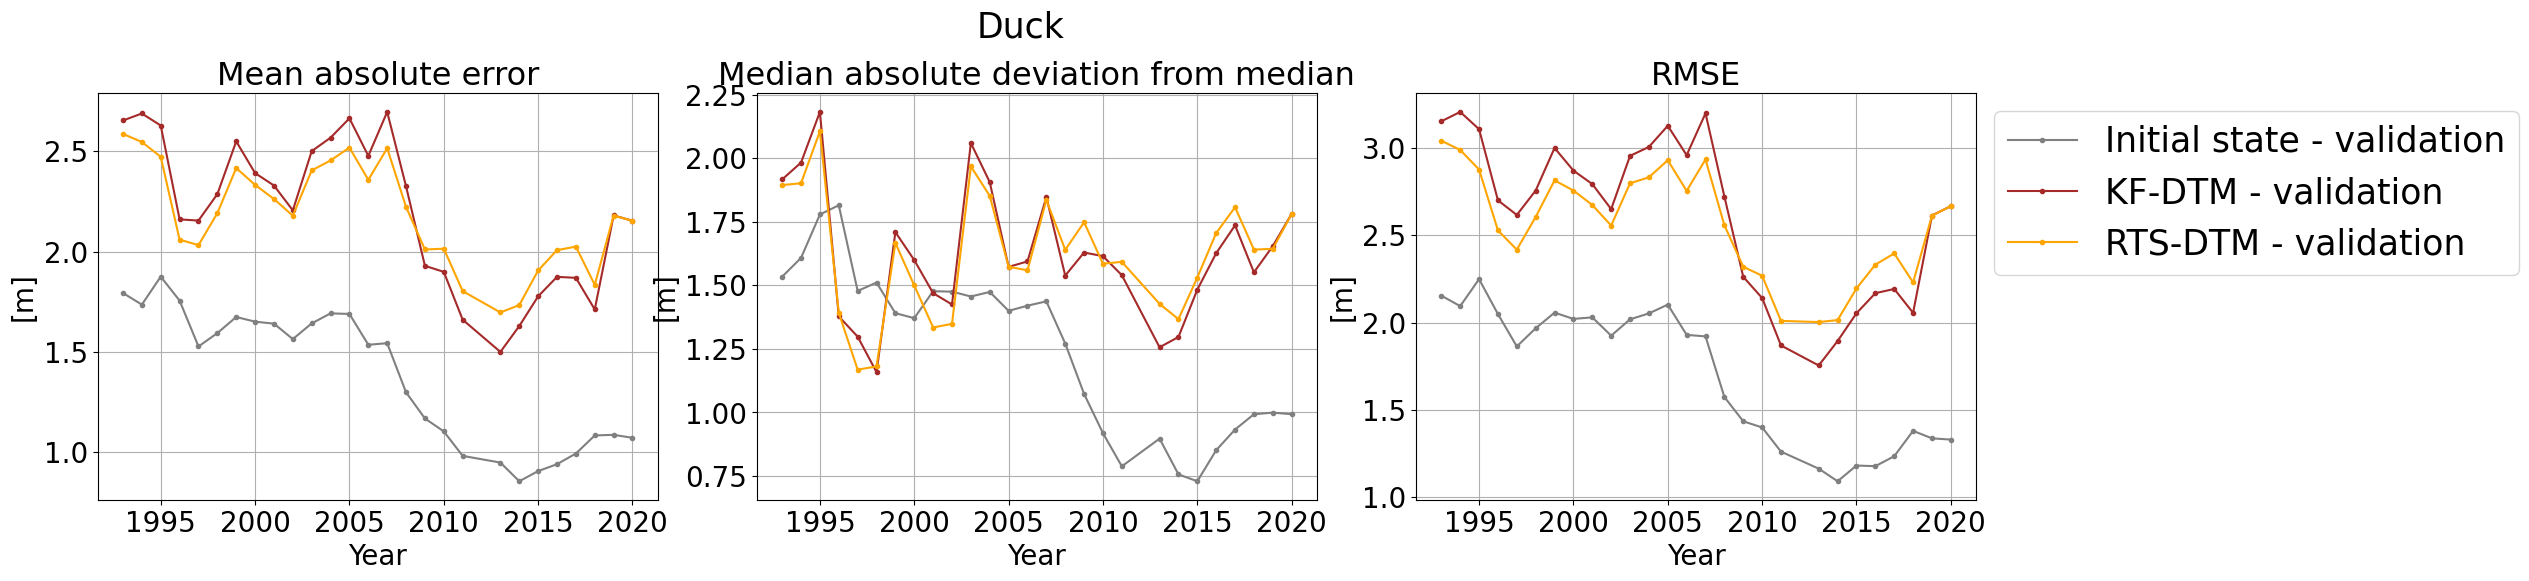

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle(f'Statistics of elevation differences averaged over the area covered by shoreline observations ({len(rts_inside_sl)} points)', y=1.1, fontsize=25)
fig.suptitle('Duck', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Duck_vali_elevation_differences.png', dpi=300, bbox_inches='tight')

#### Quantify difference init - KF/RTS
positive: init has (on average) larger error  
negative: KF/RTS has larger error  

In [25]:
print(f'Average difference init-KF (inside shoreline area):')
print(f'ME: {round((stats_gdf_init.mae - stats_gdf_kf.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init.mad_med - stats_gdf_kf.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init.rmse - stats_gdf_kf.rmse).mean(),2)} m')

print(f'\nAverage difference init-RTS (inside shoreline area):')
print(f'ME: {round((stats_gdf_init.mae - stats_gdf_rts.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init.mad_med - stats_gdf_rts.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init.rmse - stats_gdf_rts.rmse).mean(),2)} m')

Average difference init-KF (inside shoreline area):
ME: -0.82 m
MAD: -0.37 m
RMSE: -0.91 m

Average difference init-RTS (inside shoreline area):
ME: -0.8 m
MAD: -0.37 m
RMSE: -0.86 m


### Maps

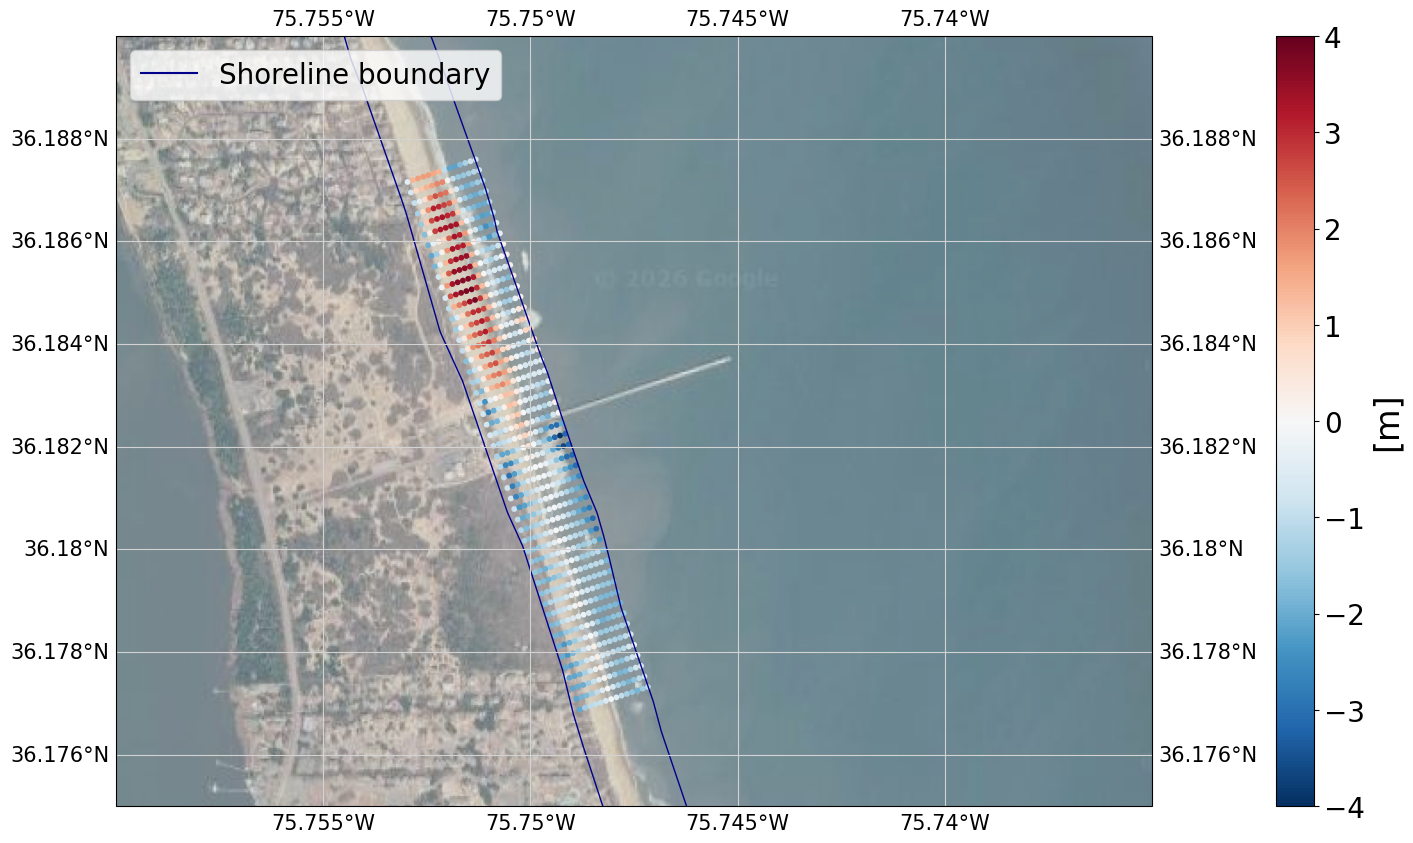

In [26]:
year = '2003'
diff_init = init_interp['init'] - vali_red[year]
diff_rts = rts_interp[year] - vali_red[year]
diff_rts_init = np.abs(diff_init) - np.abs(diff_rts)

extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

x = vali_red.geometry.x
y = vali_red.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff_rts_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

# ax.add_geometries(poly_target_red, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
# ax.set_title(f'Difference of errors initial state - RTS-DTM {year} for Duck', fontsize=24);

plt.savefig(f'{path_output}Duck_map_diff_errors_init-RTS_{year}.png', dpi=300, bbox_inches='tight')

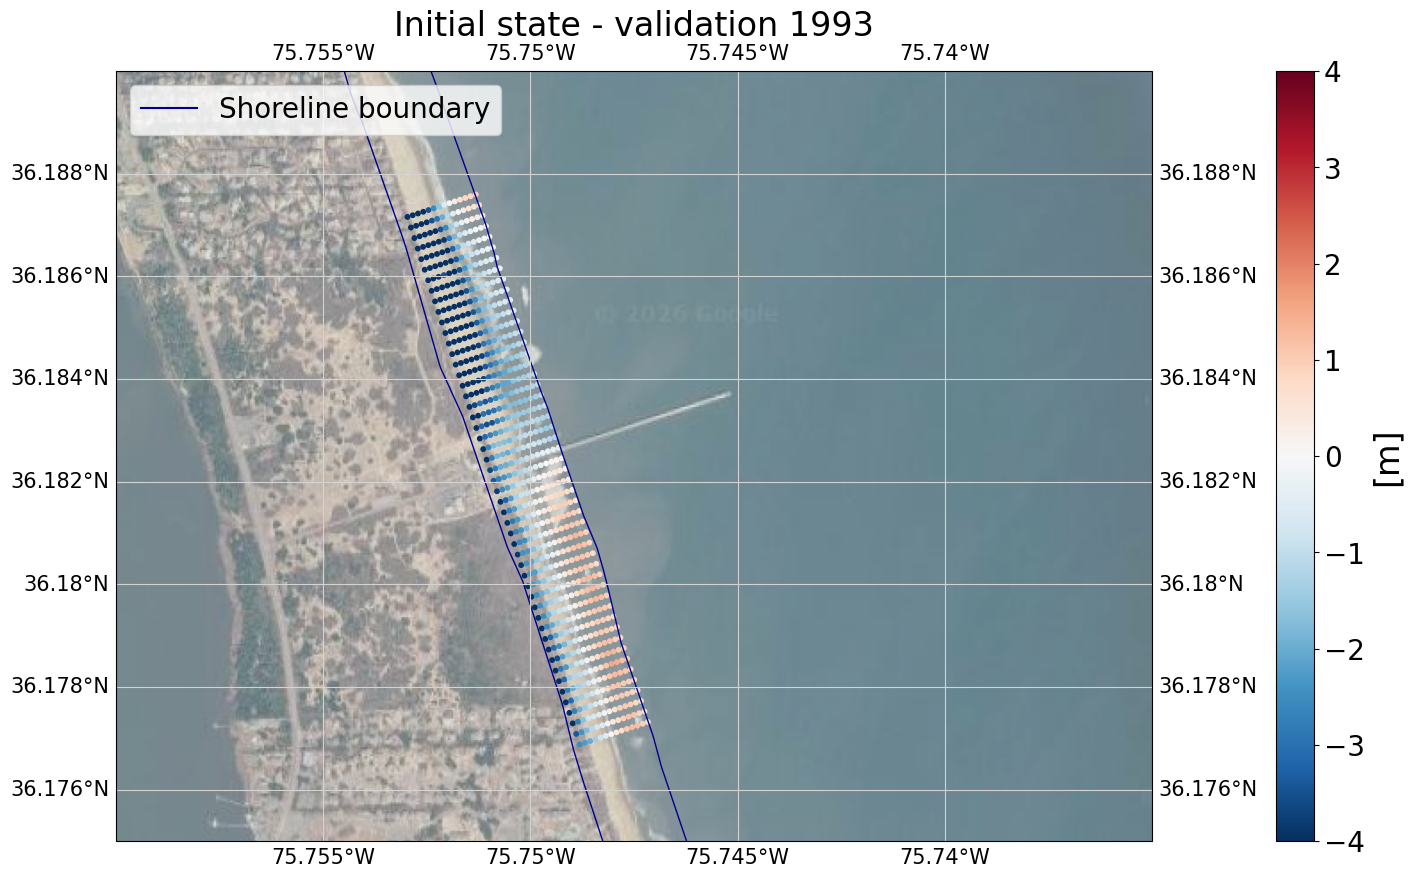

In [27]:
extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(x, y, marker='o', s=10, c=diff_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'Initial state - validation 1993', fontsize=24);

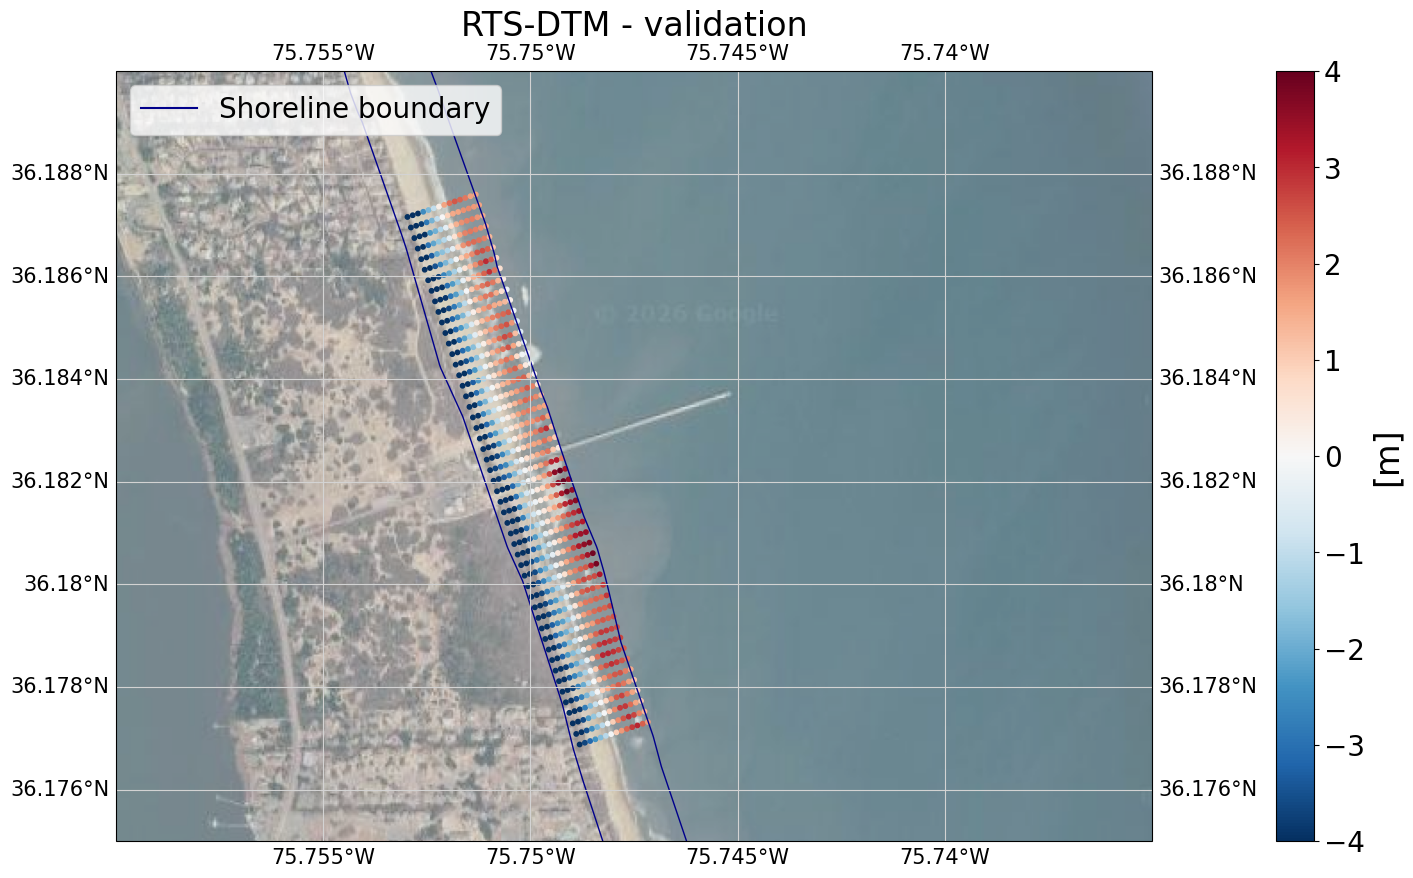

In [28]:
extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(x, y, marker='o', s=10, c=diff_rts, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'RTS-DTM - validation', fontsize=24);

## Time series of volume changes

In [29]:
volumes_vali, volumes_kf, volumes_rts = P2_functions.get_all_volumes(vali_red, kf_interp, rts_interp, transect_polys, epsg_local)

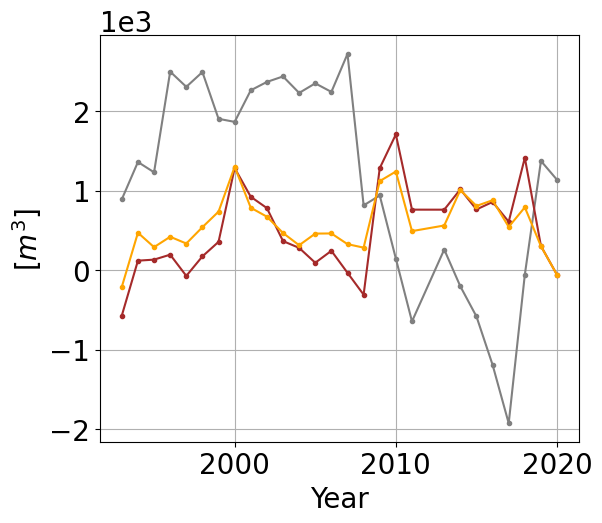

In [30]:
fig, ax = plt.subplots(figsize=(6,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.25)

ax.plot(volumes_vali.index, volumes_vali.mean(axis=1), '.-', c=c_init, label='Validation')
ax.plot(volumes_kf.index, volumes_kf.mean(axis=1), '.-', c=c_kf, label='KF-DTM')
ax.plot(volumes_rts.index, volumes_rts.mean(axis=1), '.-', c=c_rts, label='RTS-DTM')
ax.set_ylabel(r'[$m^3$]')
ax.set_xlabel('Year')
# ax.legend(bbox_to_anchor=(1,1), fontsize=22)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid()
# fig.suptitle('Volume changes Duck', fontsize=25, y=1.1)
plt.savefig(f'{path_output}Duck_validation_volume_changes.png', dpi=300, bbox_inches='tight')

### Statistics compared to the validation data set

In [31]:
trends, trend_diff_perc, corr, pvalues, rmse, rmse_perc = P2_functions.volume_stats_averaged(volumes_vali, volumes_kf, volumes_rts, print_output=True)
pickle.dump(trends, open(path_output+'Duck_validation_trends.pkl', 'wb'))

Trend differences in % of total trend: 107.96
RMSE relative to total mean volume: 120.3
Correlation:-0.24, p: 0.22


## Animation

#### KF

In [32]:
if animation:
    extent = [-75.78, -75.73, 36.16, 36.2]
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_poly.geometry.x
    y = x_state_poly.geometry.y
    anim = CD_visualisation.movie(x_state_poly, x, y,
            col_list_kf, first_col='init', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='KF.gif')

#### RTS

In [33]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_poly.geometry.x
    y = x_state_s_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='RTS.gif')

#### Single year result map